<a href="https://colab.research.google.com/github/Fahadkhan2450/Brain-MRI-Image-Classification-Using-CNN/blob/main/VGG_16Brain_MRI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
import os
import numpy as np
import random
from sklearn.model_selection import train_test_split
from PIL import Image, ImageEnhance
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense  ,GlobalAveragePooling2D,BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
from sklearn.utils import shuffle
import cv2
import zipfile
from sklearn.metrics import roc_curve, auc
import os
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
import numpy as np
import math
from tensorflow.keras.applications import ConvNeXtTiny

In [29]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".zip"):
            print(os.path.join(root, file))

/content/Brain_Tumor_Dataset/Brain Tumor MRI Dataset (Glioma, Meningioma, Pitui (1).zip
/content/Brain_Tumor_Dataset/Epic and CSCR hospital Dataset.zip


In [30]:
import zipfile
import os

zip_path = "/content/Brain_Tumor_Dataset/Epic and CSCR hospital Dataset.zip"

extract_path = "/content/Brain_Tumor_Dataset/Final"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [31]:
for root, dirs, files in os.walk("/content/Brain_Tumor_Dataset/Final"):
    print(root)
    if files:
        print("Files:", files[:5])

/content/Brain_Tumor_Dataset/Final
/content/Brain_Tumor_Dataset/Final/Epic and CSCR hospital Dataset
/content/Brain_Tumor_Dataset/Final/Epic and CSCR hospital Dataset/Test
/content/Brain_Tumor_Dataset/Final/Epic and CSCR hospital Dataset/Test/glioma
Files: ['1242.jpg', '1418.jpg', 'G_78_SP_.jpg', '1157.jpg', '1238.jpg']
/content/Brain_Tumor_Dataset/Final/Epic and CSCR hospital Dataset/Test/notumor
Files: ['1242.jpg', '1418.jpg', '1157.jpg', '1238.jpg', '1461.jpg']
/content/Brain_Tumor_Dataset/Final/Epic and CSCR hospital Dataset/Test/meningioma
Files: ['M_784.jpg', '1461.jpg', 'M_778_RO_.jpg', 'M_777_DA_.jpg', 'M_786_VF_.jpg']
/content/Brain_Tumor_Dataset/Final/Epic and CSCR hospital Dataset/Test/pituitary
Files: ['1608.jpg', '1242.jpg', '1418.jpg', 'p (43).jpg', '1238.jpg']
/content/Brain_Tumor_Dataset/Final/Epic and CSCR hospital Dataset/Train
/content/Brain_Tumor_Dataset/Final/Epic and CSCR hospital Dataset/Train/glioma
Files: ['gg (45).jpg', 'G_838_SP_.jpg', 'G_768_SP_.jpg', 'G_731

**Load and Shuffle the train data**

In [32]:
DATA_DIR = "/content/Brain_Tumor_Dataset/Final/Epic and CSCR hospital Dataset"

train_dir = os.path.join(DATA_DIR, "Train")
test_dir = os.path.join(DATA_DIR, "Test")

class_names = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])

class_to_label = {name: i for i, name in enumerate(class_names)}

print("Classes:", class_names)
print("Label mapping:", class_to_label)




















Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Label mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


**Load TRAIN paths & labels**

In [33]:
train_paths = []
train_labels = []

for class_name in class_names:
    class_dir = os.path.join(train_dir, class_name)

    for filename in os.listdir(class_dir):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            train_paths.append(os.path.join(class_dir, filename))
            train_labels.append(class_to_label[class_name])


**Shuffle TRAIN data**

In [34]:
combined = list(zip(train_paths, train_labels))

random.seed(42)
random.shuffle(combined)

train_paths, train_labels = zip(*combined)

train_paths = list(train_paths)
train_labels = list(train_labels)


**Load TEST paths & labels**

In [35]:
test_paths = []
test_labels = []

for class_name in class_names:
    class_dir = os.path.join(test_dir, class_name)

    for filename in os.listdir(class_dir):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            test_paths.append(os.path.join(class_dir, filename))
            test_labels.append(class_to_label[class_name])

**Convert labels to arrays**

In [36]:
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)

In [37]:
NUM_CLASSES = len(class_names)

print("Number of classes:", NUM_CLASSES)
print("Classes:", class_names)

Number of classes: 4
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


**Check**

In [38]:
print("\nTraining samples:", len(train_paths))
print("Training labels:", len(train_labels))

print("Testing samples:", len(test_paths))
print("Testing labels:", len(test_labels))

print("\nFirst 5 training paths:")
print(train_paths[:5])

print("\nFirst 5 training labels:")
print(train_labels[:5])


Training samples: 9650
Training labels: 9650
Testing samples: 2414
Testing labels: 2414

First 5 training paths:
['/content/Brain_Tumor_Dataset/Final/Epic and CSCR hospital Dataset/Train/meningioma/Tr-me_1172.jpg', '/content/Brain_Tumor_Dataset/Final/Epic and CSCR hospital Dataset/Train/pituitary/P_772.jpg', '/content/Brain_Tumor_Dataset/Final/Epic and CSCR hospital Dataset/Train/meningioma/M_856_VF_.jpg', '/content/Brain_Tumor_Dataset/Final/Epic and CSCR hospital Dataset/Train/meningioma/Tr-me_0288.jpg', '/content/Brain_Tumor_Dataset/Final/Epic and CSCR hospital Dataset/Train/notumor/22 no.jpg']

First 5 training labels:
[1 3 1 1 2]


**Validating Images**

In [39]:
plt.figure(figsize=(10, 8))

for images, labels in train_data.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_data.class_names[labels[i]])
        plt.axis("off")

NameError: name 'train_data' is not defined

<Figure size 1000x800 with 0 Axes>

**Sample Random Indices and their visualization**

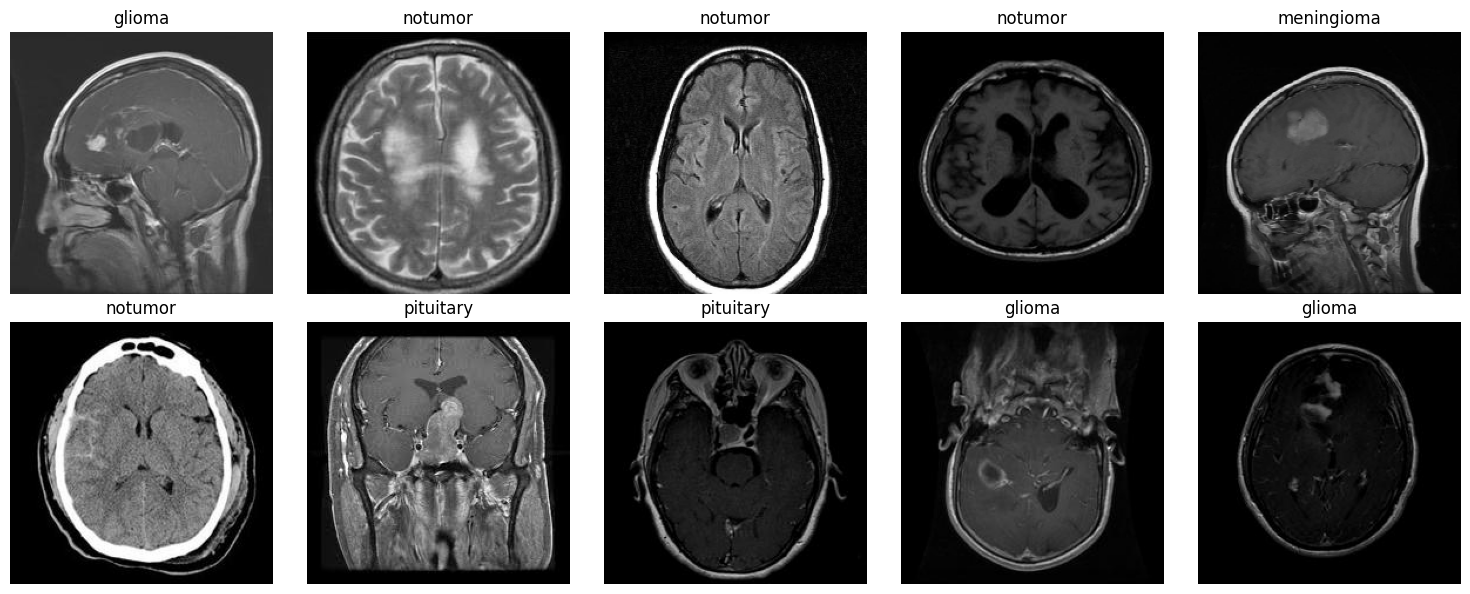

In [40]:

random_indices = random.sample(range(len(train_paths)), 10)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i, idx in enumerate(random_indices):

    img = load_img(
        train_paths[idx],
        target_size=(224, 224)
    )

    axes[i].imshow(img)
    axes[i].set_title(class_names[train_labels[idx]])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

**Image Preprocessing**

In [41]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

NameError: name 'tf' is not defined

**Image_Augmentation**

In [42]:
def augment_image(image):

    # Random horizontal flip
    if random.random() < 0.5:
        image = cv2.flip(image, 1)

    # Random rotation
    if random.random() < 0.5:
        angle = random.uniform(-10, 10)

        h, w = image.shape[:2]
        center = (w // 2, h // 2)

        matrix = cv2.getRotationMatrix2D(
            center,
            angle,
            1.0
        )

        image = cv2.warpAffine(
            image,
            matrix,
            (w, h),
            borderMode=cv2.BORDER_REFLECT
        )

    # Random brightness
    if random.random() < 0.3:
        factor = random.uniform(0.9, 1.1)
        image = image * factor

    image = np.clip(image, 0, 255)

    return image

**Open_Images**

In [43]:
from tensorflow.keras.applications.vgg16 import preprocess_input

def open_images(paths):

    images = []

    for path in paths:

        image = cv2.imread(path)

        if image is None:
            continue

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        image = cv2.resize(
            image,
            (128, 128),
            interpolation=cv2.INTER_AREA
        )

        images.append(image.astype(np.float32))

    return np.array(images, dtype=np.float32)

**Encode Labels**

In [44]:
def encode_label(labels):

    labels = np.array(labels)

    encoded = np.zeros(
        (len(labels), NUM_CLASSES),
        dtype=np.float32
    )

    encoded[np.arange(len(labels)), labels] = 1

    return encoded

**Data Generator**

In [45]:
def data_gen(paths, labels, batch_size):

    while True:

        indices = np.arange(len(paths))
        np.random.shuffle(indices)

        for start in range(0, len(paths), batch_size):

            batch_indices = indices[
                start:start + batch_size
            ]

            batch_paths = [
                paths[i] for i in batch_indices
            ]

            batch_labels = [
                labels[i] for i in batch_indices
            ]

            images = open_images(batch_paths)

            augmented_images = []

            for image in images:

                image = augment_image(
                    image.astype(np.uint8)
                )

                augmented_images.append(image)

            images = np.array(
                augmented_images,
                dtype=np.float32
            )

            # Apply VGG16 preprocessing ONCE
            images = preprocess_input(images)

            labels_encoded = encode_label(batch_labels)

            yield images, labels_encoded

In [46]:
train_generator = data_gen(
    train_paths,
    train_labels,
    batch_size=32
)

images, labels = next(train_generator)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: (32, 128, 128, 3)
Labels shape: (32, 4)


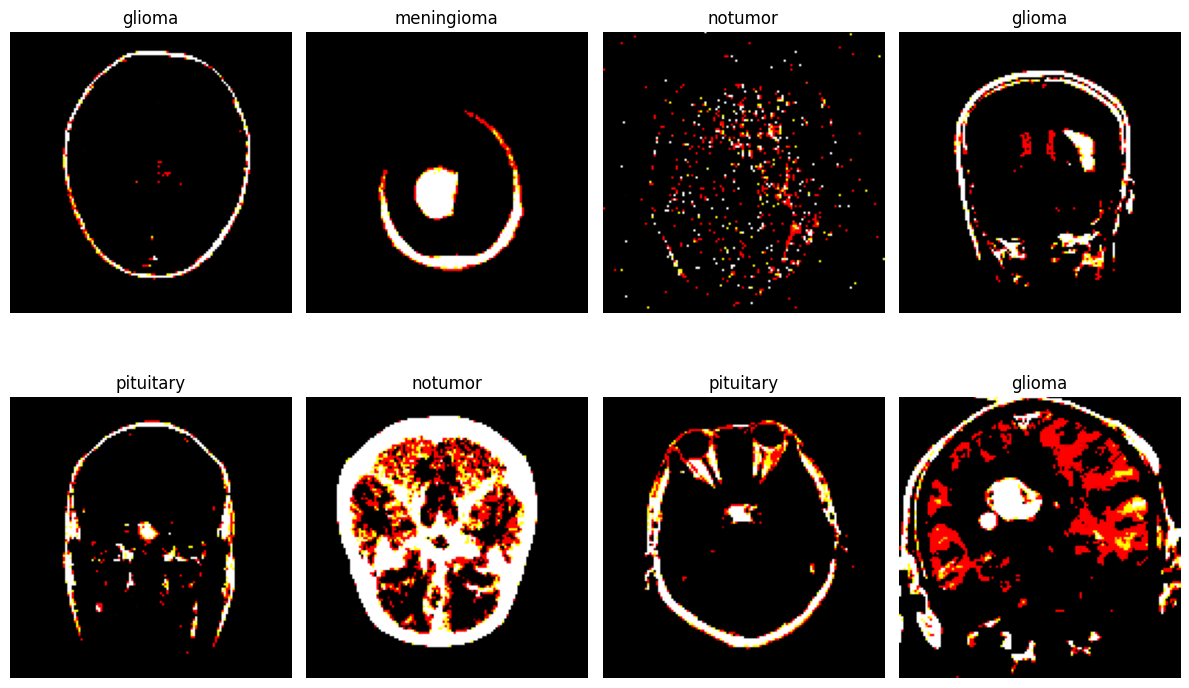

In [47]:
plt.figure(figsize=(12, 8))

for i in range(8):
    plt.subplot(2, 4, i + 1)

    plt.imshow(images[i])

    label_index = np.argmax(labels[i])
    plt.title(class_names[label_index])

    plt.axis("off")

plt.tight_layout()
plt.show()

**Model Architecture**

In [48]:
image_size=128
base_model=VGG16(input_shape=(image_size,image_size,3),include_top=False,weights='imagenet')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


**Freeze all layers for VGG16**

In [49]:
for layer in base_model.layers:
  layer.trainable=False

**Set Only The last few Layers**

In [50]:
base_model.layers[-2].trainable=True
base_model.layers[-3].trainable=True
base_model.layers[-4].trainable=True

**Build The final model**

In [51]:
model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(4, activation='softmax')
])

In [52]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**Train/Test/Validation Split**

In [53]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths,
    train_labels,
    test_size=0.2,
    random_state=42,
    stratify=train_labels
)

print("Training:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))

Training: 7720
Validation: 1930
Test: 2414


**Parameters**

In [54]:
def val_data_gen(paths, labels, batch_size):

    while True:

        for start in range(0, len(paths), batch_size):

            batch_paths = paths[
                start:start + batch_size
            ]

            batch_labels = labels[
                start:start + batch_size
            ]

            images = open_images(batch_paths)

            # Same preprocessing as training
            images = preprocess_input(images)

            labels_encoded = encode_label(batch_labels)

            yield images, labels_encoded

In [55]:
BATCH_SIZE = 32

train_generator = data_gen(
    train_paths,
    train_labels,
    BATCH_SIZE
)

val_generator = val_data_gen(
    val_paths,
    val_labels,
    BATCH_SIZE
)

test_generator = val_data_gen(
    test_paths,
    test_labels,
    BATCH_SIZE
)

In [56]:
val_generator = val_data_gen(
    val_paths,
    val_labels,
    BATCH_SIZE
)

test_generator = val_data_gen(
    test_paths,
    test_labels,
    BATCH_SIZE
)

**Callbacks**

In [57]:
callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        'best_vgg16_finetuned.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

**Fit Model**

In [58]:
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_paths) // BATCH_SIZE,
    validation_data=val_generator,
    validation_steps=len(val_paths) // BATCH_SIZE,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.3611 - loss: 1.7570
Epoch 1: val_loss improved from None to 0.80494, saving model to best_vgg16_finetuned.keras

Epoch 1: finished saving model to best_vgg16_finetuned.keras
241/241 ━━━━━━━━━━━━━━━━━━━━ 39s 111ms/step - accuracy: 0.4522 - loss: 1.4758 - val_accuracy: 0.7208 - val_loss: 0.8049 - learning_rate: 1.0000e-05
Epoch 2/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.6058 - loss: 1.0606
Epoch 2: val_loss improved from 0.80494 to 0.69048, saving model to best_vgg16_finetuned.keras

Epoch 2: finished saving model to best_vgg16_finetuned.keras
241/241 ━━━━━━━━━━━━━━━━━━━━ 30s 105ms/step - accuracy: 0.6328 - loss: 0.9976 - val_accuracy: 0.7750 - val_loss: 0.6905 - learning_rate: 1.0000e-05
Epoch 3/20
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.6990 - loss: 0.8253
Epoch 3: val_loss improved from 0.69048 to 0.49207, saving model to best_vgg16_finetuned.keras

Epoch 3: finished saving model to be

**Visualizing Validation and Acuuarcy**

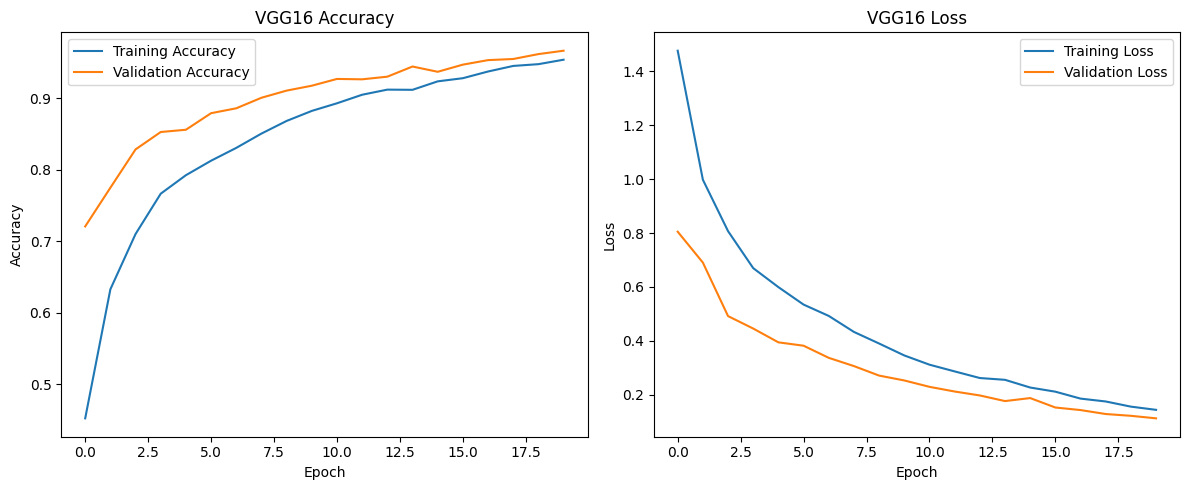

In [59]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('VGG16 Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VGG16 Loss')
plt.legend()

plt.tight_layout()
plt.show()

**Get Predictions**

In [60]:

test_steps = math.ceil(len(test_paths) / BATCH_SIZE)
y_prob = model.predict(
    test_generator,
    steps=test_steps,
    verbose=1
)


y_pred = np.argmax(y_prob, axis=1)


y_true = np.array(test_labels)

76/76 ━━━━━━━━━━━━━━━━━━━━ 11s 136ms/step


**Length Matching**

In [61]:
y_pred = y_pred[:len(y_true)]
y_true = y_true[:len(y_pred)]

print("Actual labels:", len(y_true))
print("Predicted labels:", len(y_pred))

Actual labels: 2414
Predicted labels: 2414


**CLassification Report**

In [62]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

              precision    recall  f1-score   support

      glioma     0.9649    0.8742    0.9173       755
  meningioma     0.8891    0.9249    0.9066       546
     notumor     0.9487    0.9877    0.9678       487
   pituitary     0.9450    0.9888    0.9664       626

    accuracy                         0.9383      2414
   macro avg     0.9369    0.9439    0.9395      2414
weighted avg     0.9393    0.9383    0.9378      2414



**Confusion Matrix Figure**

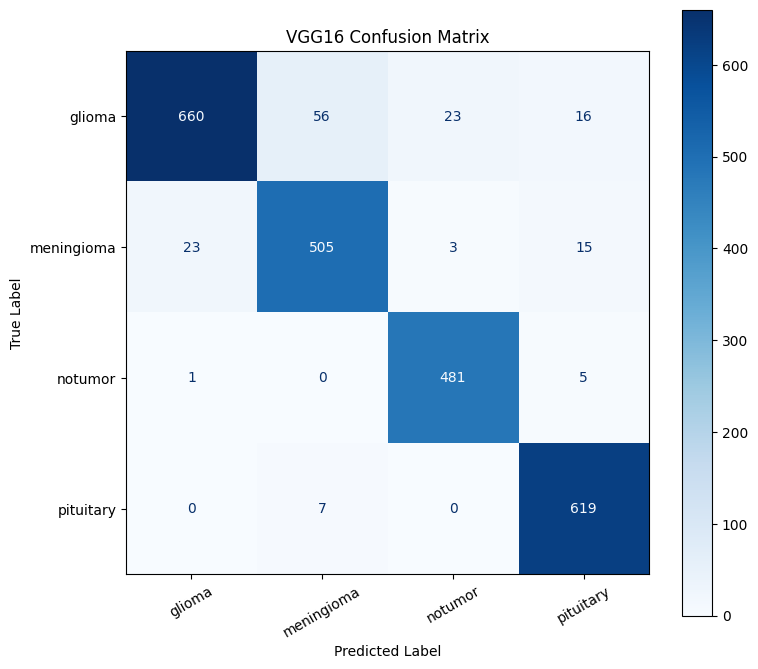

In [69]:
# Convert probabilities to class indices
y_pred = np.argmax(y_prob, axis=1)
y_pred = y_pred[:len(test_labels)]
y_true = np.array(test_labels)[:len(y_pred)]

# Confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=plt.gca()
)

plt.title("VGG16 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Testing from the test images and analyzing about actual vs predicted**

In [70]:

# Get predictions
test_steps = math.ceil(len(test_paths) / BATCH_SIZE)

y_prob = model.predict(
    test_generator,
    steps=test_steps,
    verbose=1
)

# Keep only actual test samples
y_prob = y_prob[:len(test_labels)]

# Predicted class indices
y_pred = np.argmax(y_prob, axis=1)

# Actual class indices
y_true = np.array(test_labels)

# Create comparison dataframe
results = pd.DataFrame({
    "Image": [os.path.basename(path) for path in test_paths],
    "Actual": [class_names[i] for i in y_true],
    "Predicted": [class_names[i] for i in y_pred],
    "Confidence": np.max(y_prob, axis=1) * 100
})

print(results.head(20))

76/76 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step
            Image  Actual   Predicted  Confidence
0        1242.jpg  glioma      glioma   99.902664
1        1418.jpg  glioma      glioma   99.948944
2    G_78_SP_.jpg  glioma      glioma   99.688225
3        1157.jpg  glioma      glioma   99.970657
4        1238.jpg  glioma      glioma   57.377537
5        1461.jpg  glioma      glioma   99.896431
6        1291.jpg  glioma      glioma   76.551765
7    G_83_SP_.jpg  glioma      glioma   98.679527
8   G_685_VF_.jpg  glioma      glioma   99.981247
9   G_691_DA_.jpg  glioma      glioma   98.979515
10       G_80.jpg  glioma      glioma   99.956543
11       G_77.jpg  glioma     notumor   94.438232
12  G_698_RO_.jpg  glioma      glioma   99.863808
13  G_685_RO_.jpg  glioma      glioma   99.699577
14   G_82_BR_.jpg  glioma      glioma   99.865112
15       1171.jpg  glioma      glioma   99.505783
16       1210.jpg  glioma  meningioma   98.567139
17       1160.jpg  glioma      glioma   99.880196
18  G_688_

**Visulazing actual vs predicted results**

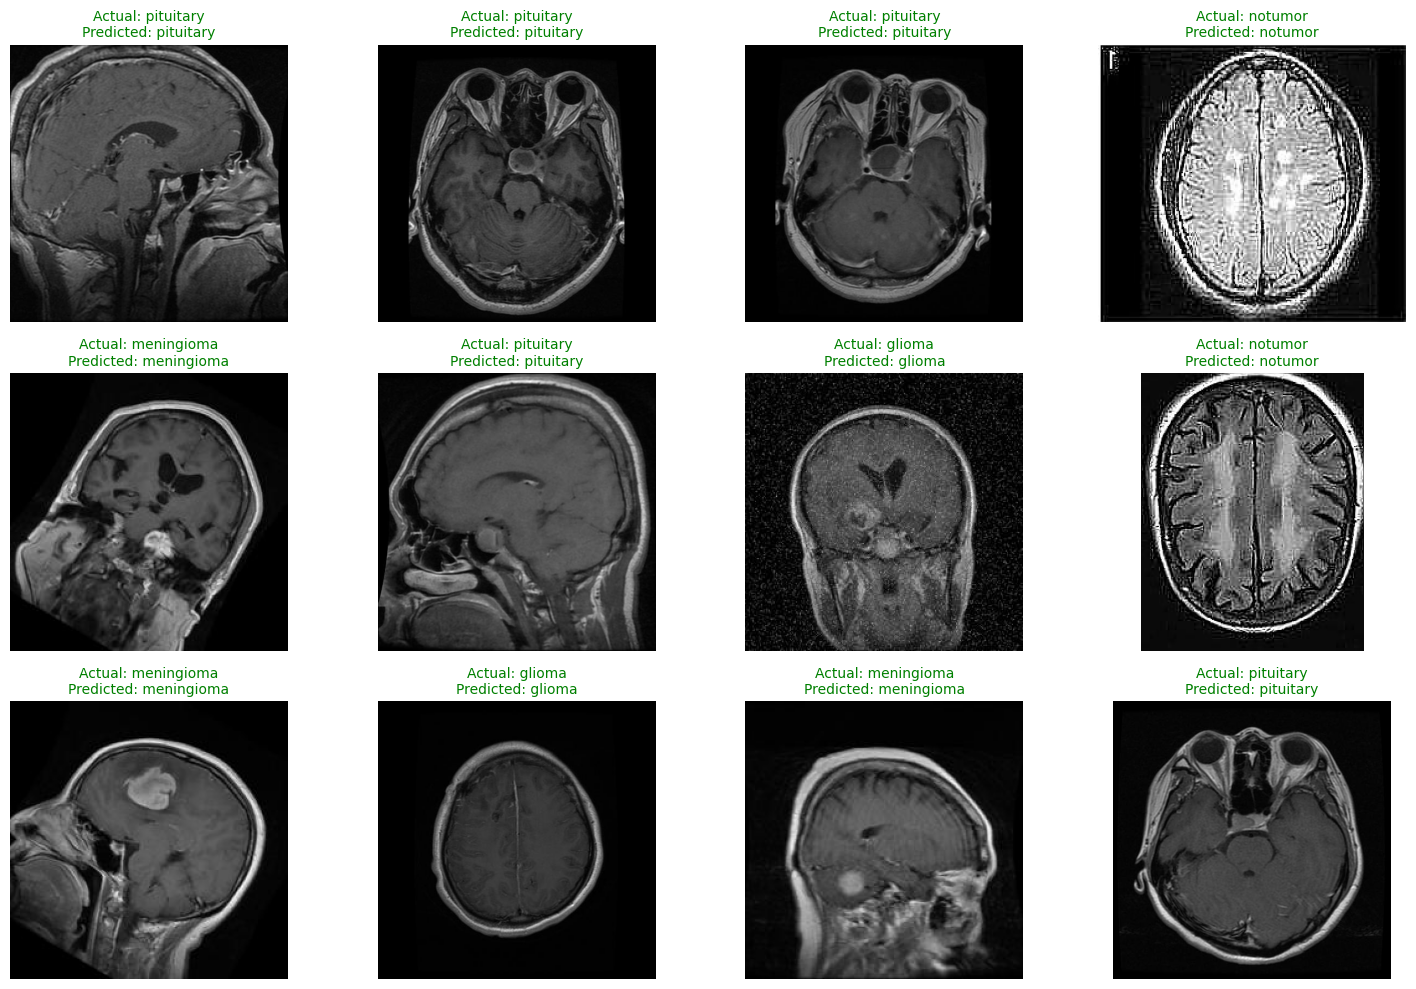

In [71]:
indices = random.sample(
    range(len(test_paths)),
    12
)

plt.figure(figsize=(15, 10))

for i, idx in enumerate(indices):

    image = cv2.imread(test_paths[idx])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    actual = class_names[y_true[idx]]
    predicted = class_names[y_pred[idx]]

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)

    color = "green" if actual == predicted else "red"

    plt.title(
        f"Actual: {actual}\n"
        f"Predicted: {predicted}",
        color=color,
        fontsize=10
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [72]:
model.save("/content/vgg16_brain_tumor.keras")

In [73]:
import os

print(
    os.path.getsize("/content/vgg16_brain_tumor.keras") / (1024**2),
    "MB"
)

112.15198707580566 MB


**Download VGG 16 model**

In [74]:
from google.colab import files

files.download("/content/vgg16_brain_tumor.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [75]:
print("Model input:", model.input_shape)
print("Model output:", model.output_shape)
print("Classes:", class_names)

Model input: (None, 128, 128, 3)
Model output: (None, 4)
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [76]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

classes_to_test = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

for class_name in classes_to_test:

    folder = os.path.join(
        test_dir,
        class_name
    )

    image_file = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ][0]

    image_path = os.path.join(
        folder,
        image_file
    )

    # Load exactly like training
    image = cv2.imread(image_path)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    image = cv2.resize(
        image,
        (128, 128),
        interpolation=cv2.INTER_AREA
    )

    image = image.astype(
        np.float32
    ) / 255.0

    image = np.expand_dims(
        image,
        axis=0
    )

    prediction = model.predict(
        image,
        verbose=0
    )[0]

    predicted_index = np.argmax(prediction)

    print("\n==============================")
    print("ACTUAL:", class_name)
    print("IMAGE:", image_file)

    for i, name in enumerate(class_names):
        print(
            f"{name:15s}: {prediction[i]*100:.2f}%"
        )

    print(
        "PREDICTED:",
        class_names[predicted_index]
    )


ACTUAL: glioma
IMAGE: 1242.jpg
glioma         : 83.66%
meningioma     : 2.99%
notumor        : 11.14%
pituitary      : 2.20%
PREDICTED: glioma

ACTUAL: meningioma
IMAGE: M_784.jpg
glioma         : 81.35%
meningioma     : 3.30%
notumor        : 12.55%
pituitary      : 2.81%
PREDICTED: glioma

ACTUAL: notumor
IMAGE: 1242.jpg
glioma         : 82.67%
meningioma     : 2.87%
notumor        : 11.74%
pituitary      : 2.72%
PREDICTED: glioma

ACTUAL: pituitary
IMAGE: 1608.jpg
glioma         : 80.43%
meningioma     : 3.27%
notumor        : 12.96%
pituitary      : 3.34%
PREDICTED: glioma


In [77]:
import tensorflow as tf
import numpy as np

loaded_model = tf.keras.models.load_model(
    "/content/vgg16_brain_tumor.keras"
)

print(loaded_model.input_shape)
print(loaded_model.output_shape)

(None, 128, 128, 3)
(None, 4)


In [78]:
test_loss, test_accuracy = loaded_model.evaluate(
    test_generator,
    steps=int(np.ceil(len(test_paths) / BATCH_SIZE)),
    verbose=1
)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

76/76 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.9383 - loss: 0.2015
Test Accuracy: 0.9382767081260681
Test Loss: 0.20154087245464325


In [80]:
for class_name in class_names:

    folder = os.path.join(test_dir, class_name)

    image_files = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    image_path = os.path.join(
        folder,
        image_files[0]
    )

    # EXACT same preprocessing as test_generator
    image = open_images([image_path])

    prediction = model.predict(
        image,
        verbose=0
    )[0]

    predicted_index = np.argmax(prediction)

    print("\n==============================")
    print("ACTUAL:", class_name)
    print("IMAGE:", image_files[0])

    for i, name in enumerate(class_names):
        print(
            f"{name:15s}: {prediction[i] * 100:.2f}%"
        )

    print(
        "PREDICTED:",
        class_names[predicted_index]
    )


ACTUAL: glioma
IMAGE: 1242.jpg
glioma         : 97.98%
meningioma     : 0.28%
notumor        : 1.58%
pituitary      : 0.15%
PREDICTED: glioma

ACTUAL: meningioma
IMAGE: M_784.jpg
glioma         : 9.88%
meningioma     : 89.09%
notumor        : 0.48%
pituitary      : 0.55%
PREDICTED: meningioma

ACTUAL: notumor
IMAGE: 1242.jpg
glioma         : 0.10%
meningioma     : 0.00%
notumor        : 94.06%
pituitary      : 5.84%
PREDICTED: notumor

ACTUAL: pituitary
IMAGE: 1608.jpg
glioma         : 1.47%
meningioma     : 5.14%
notumor        : 6.69%
pituitary      : 86.70%
PREDICTED: pituitary


# **ConvneXt FOR BRAIN MRI IMAGES**

In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

**Image Augmentation**

In [ ]:
def augment_image(image):

    image = image.astype(np.float32)

    # Small rotation
    if random.random() < 0.5:

        angle = random.uniform(-8, 8)

        h, w = image.shape[:2]
        center = (w // 2, h // 2)

        matrix = cv2.getRotationMatrix2D(
            center,
            angle,
            1.0
        )

        image = cv2.warpAffine(
            image,
            matrix,
            (w, h),
            borderMode=cv2.BORDER_REFLECT
        )

    # Small translation
    if random.random() < 0.25:

        tx = random.uniform(-0.05, 0.05) * image.shape[1]
        ty = random.uniform(-0.05, 0.05) * image.shape[0]

        matrix = np.float32([
            [1, 0, tx],
            [0, 1, ty]
        ])

        image = cv2.warpAffine(
            image,
            matrix,
            (image.shape[1], image.shape[0]),
            borderMode=cv2.BORDER_REFLECT
        )

    # Mild brightness
    if random.random() < 0.3:

        factor = random.uniform(0.95, 1.05)
        image = image * factor

    # Mild contrast
    if random.random() < 0.3:

        mean = np.mean(image)

        factor = random.uniform(0.95, 1.05)

        image = (
            (image - mean) * factor
            + mean
        )

    return np.clip(
        image,
        0,
        255
    ).astype(np.uint8)

**Open Images**

In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

def open_images(paths):

    images = []

    for path in paths:

        image = cv2.imread(path)

        if image is None:
            continue

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        image = cv2.resize(
            image,
            IMG_SIZE,
            interpolation=cv2.INTER_AREA
        )

        images.append(
            image.astype(np.float32)
        )

    return np.array(
        images,
        dtype=np.float32
    )

**Encode labels**

In [ ]:
def encode_label(labels):

    labels = np.array(labels)

    encoded = np.zeros(
        (len(labels), NUM_CLASSES),
        dtype=np.float32
    )

    encoded[
        np.arange(len(labels)),
        labels
    ] = 1

    return encoded

***Convnext data generator***

In [ ]:
def data_gen(paths, labels, batch_size):

    while True:

        indices = np.random.permutation(len(paths))

        for start in range(0, len(paths), batch_size):

            batch_indices = indices[
                start:start + batch_size
            ]

            batch_paths = [
                paths[i] for i in batch_indices
            ]

            batch_labels = labels[batch_indices]

            # Load images
            images = open_images(batch_paths)

            # Augment
            images = np.array([
                augment_image(image.astype(np.uint8))
                for image in images
            ], dtype=np.float32)

            # One-hot labels
            labels_encoded = encode_label(
                batch_labels
            )

            yield images, labels_encoded

**val/Test geneartor**

In [ ]:
def val_data_gen(paths, labels, batch_size):

    while True:

        for start in range(
            0,
            len(paths),
            batch_size
        ):

            batch_paths = paths[
                start:start + batch_size
            ]

            batch_labels = labels[
                start:start + batch_size
            ]

            images = open_images(batch_paths)

            labels_encoded = encode_label(
                batch_labels
            )

            yield images, labels_encoded

In [ ]:
train_generator = data_gen(
    train_paths,
    train_labels,
    BATCH_SIZE
)

val_generator = val_data_gen(
    val_paths,
    val_labels,
    BATCH_SIZE
)

test_generator = val_data_gen(
    test_paths,
    test_labels,
    BATCH_SIZE
)

**Checking convnext generator created**

In [ ]:
images, labels = next(train_generator)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

print("Image minimum:", images.min())
print("Image maximum:", images.max())

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(8):

    plt.subplot(2, 4, i + 1)

    plt.imshow(
        images[i].astype(np.uint8)
    )

    label_index = np.argmax(labels[i])

    plt.title(
        class_names[label_index]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

**Load Model**

In [ ]:
tf.keras.backend.clear_session()

IMG_SIZE = (128, 128)
NUM_CLASSES = 4

# ==========================================
# ConvNeXtTiny
# ==========================================

base_model = ConvNeXtTiny(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze backbone
base_model.trainable = False


# ==========================================
# Small classification head
# ==========================================

model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dropout(0.5),

    Dense(
        64,
        activation="relu",
        kernel_regularizer=l2(1e-4)
    ),

    Dropout(0.4),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

model.build((None, 128, 128, 3))

model.compile(
    optimizer=Adam(
        learning_rate=1e-4
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

In [ ]:
callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        "best_convnext_tiny.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_generator,
    validation_steps=validation_steps,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

In [ ]:
image_size = 128

base_model = ConvNeXtTiny(
    input_shape=(image_size,image_size, 3),
    include_top=False,
    weights="imagenet"
)

**Freeze Model**

**Classification Head**

**Training Parameters**

In [ ]:
tf.keras.backend.clear_session()

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
NUM_CLASSES = 4

# ==========================================
# ConvNeXtTiny
# ==========================================

base_model = ConvNeXtTiny(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze backbone initially
for layer in base_model.layers:
    layer.trainable = False


# ==========================================
# Classification Head
# ==========================================

model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(1e-4)
    ),

    BatchNormalization(),

    Dropout(0.5),

    Dense(
        64,
        activation="relu",
        kernel_regularizer=l2(1e-4)
    ),

    Dropout(0.4),

    Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

model.build((None, 128, 128, 3))

model.compile(
    optimizer=Adam(
        learning_rate=3e-4
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

In [ ]:
callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        "best_convnext_tiny.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_generator,
    validation_steps=validation_steps,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("ConvNeXtTiny Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)


plt.subplot(1, 2, 2)

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("ConvNeXtTiny Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import math
import numpy as np
import pandas as pd

# Create fresh test generator
test_generator = val_data_gen(
    test_paths,
    test_labels,
    BATCH_SIZE
)

test_steps = math.ceil(
    len(test_paths) / BATCH_SIZE
)

# Predict
y_prob = model.predict(
    test_generator,
    steps=test_steps,
    verbose=1
)

# Remove any extra predictions from the last batch
y_prob = y_prob[:len(test_paths)]

# Predicted class
y_pred = np.argmax(y_prob, axis=1)

# Actual class
y_true = np.array(test_labels)

print("Predictions shape:", y_prob.shape)
print("Actual labels:", y_true.shape)
print("Predicted labels:", y_pred.shape)

In [ ]:
results = pd.DataFrame({
    "Image": [
        os.path.basename(path)
        for path in test_paths
    ],

    "Actual": [
        class_names[i]
        for i in y_true
    ],

    "Predicted": [
        class_names[i]
        for i in y_pred
    ],

    "Confidence": [
        np.max(prob) * 100
        for prob in y_prob
    ]
})

results["Correct"] = (
    results["Actual"] == results["Predicted"]
)

print(
    results.head(30).to_string(index=False)
)

In [ ]:
accuracy = np.mean(
    y_true == y_pred
)

print(
    f"Test Accuracy: {accuracy * 100:.2f}%"
)

In [ ]:
import matplotlib.pyplot as plt
import random
import cv2

indices = random.sample(
    range(len(test_paths)),
    12
)

plt.figure(figsize=(14, 10))

for i, idx in enumerate(indices):

    image = cv2.imread(
        test_paths[idx]
    )

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    actual = class_names[y_true[idx]]
    predicted = class_names[y_pred[idx]]
    confidence = np.max(y_prob[idx]) * 100

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    if actual == predicted:
        title_color = "green"
    else:
        title_color = "red"

    plt.title(
        f"Actual: {actual}\n"
        f"Predicted: {predicted}\n"
        f"Confidence: {confidence:.1f}%",
        color=title_color,
        fontsize=10
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
model.save("/content/vgg16_brain_tumor.keras")

In [ ]:
from google.colab import files

files.download(
    "/content/vgg16_brain_tumor.keras"
)